#Dataset Collection

In [120]:
# Loading dataset in variable df

df = pd.read_csv('/content/patient_data.csv')
df.head()

,C,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


#Data Preparation

In [121]:
# Loading important libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [122]:
df.isnull().sum()

,0
C,0
Age,0
History,0
Patient,0
TakeMedication,0
Severity,0
BreathShortness,0
VisualChanges,0
NoseBleeding,0
Whendiagnoused,0


In [123]:
df.rename(columns={'C':'Gender'}, inplace=True)
df

,Gender,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,Female,35-50,Yes,No,No,Sever,No,No,No,>5 Years,111 - 120,70 - 80,No,NORMAL
1821,Male,51-64,Yes,No,No,Sever,No,No,No,>5 Years,111 - 120,70 - 80,No,NORMAL
1822,Female,51-64,Yes,No,No,Sever,No,No,No,>5 Years,111 - 120,70 - 80,No,NORMAL
1823,Male,65+,Yes,No,No,Sever,No,No,No,>5 Years,111 - 120,70 - 80,No,NORMAL


In [124]:
df['TakeMedication'].replace({'Yes ':'Yes'}, inplace=True)
df['NoseBleeding'].replace({'No ':'No'}, inplace=True)
df['Systolic'].replace({'100+':'100 - 110'}, inplace=True)
df['Systolic'].replace({'121- 130':'121 - 130'}, inplace=True)
df['Stages'].replace({'HYPERTENSION (Stage-2).':'HYPERTENSION (Stage-2)'}, inplace=True)
df['Stages'].replace({'HYPERTENSIVE CRISI':'HYPERTENSION CRISIS'}, inplace=True)
df['Stages'].replace({'HYPERTENSION CRISIS':'HYPERTENSIVE CRISIS'}, inplace=True)
df

print((df['Diastolic']=='130+').sum())
print((df['Diastolic']=='100+').sum())

4
237


/tmp/ipykernel_335/270991789.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TakeMedication'].replace({'Yes ':'Yes'}, inplace=True)
/tmp/ipykernel_335/270991789.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [125]:
df['Diastolic'].replace({'130+':'100+'}, inplace=True)

/tmp/ipykernel_335/1944431796.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Diastolic'].replace({'130+':'100+'}, inplace=True)


In [126]:
print(df.duplicated().sum())

477


In [127]:
df.drop_duplicates(inplace=True)

/tmp/ipykernel_335/2842954295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Gender", palette="Set2")


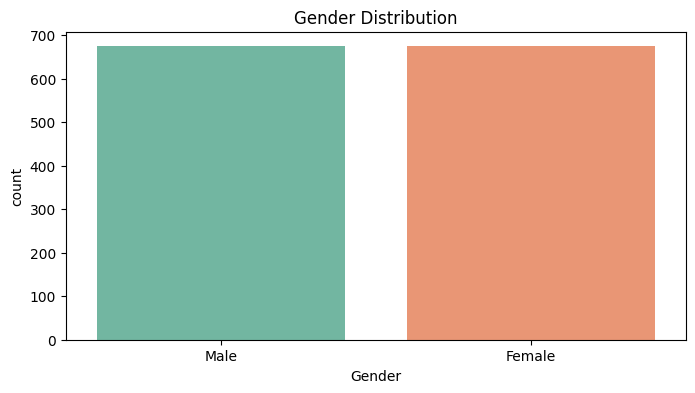

In [128]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Gender", palette="Set2")

plt.title("Gender Distribution")
plt.show()

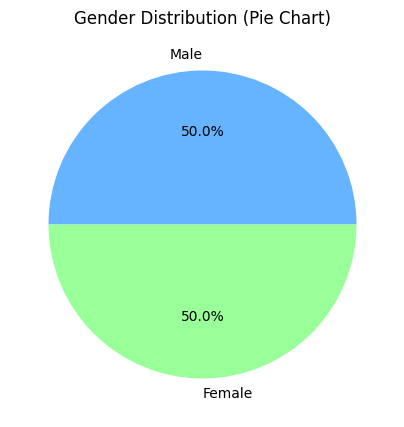

In [129]:
# Pie chart for Gender
df['Gender'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(5,5),
    colors=['#66b3ff', '#99ff99']
)

plt.title("Gender Distribution (Pie Chart)")
plt.ylabel("")
plt.show()

In [130]:
df['Stages'].unique()

array(['HYPERTENSION (Stage-1)', 'HYPERTENSION (Stage-2)',
       'HYPERTENSIVE CRISIS', 'NORMAL'], dtype=object)

/tmp/ipykernel_335/2500281062.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Stages", palette="coolwarm")


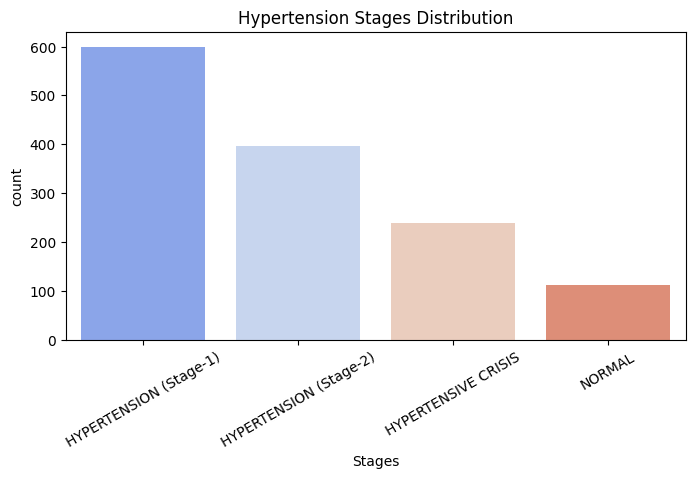

In [131]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Stages", palette="coolwarm")

plt.title("Hypertension Stages Distribution")
plt.xticks(rotation=30)
plt.show()

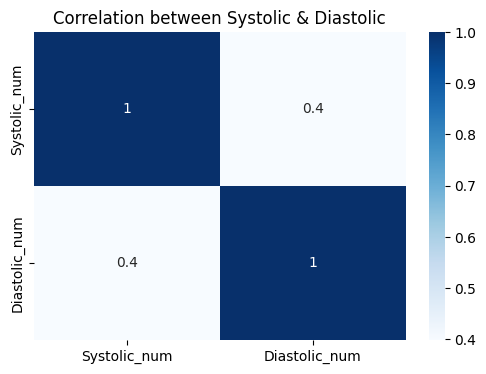

In [133]:
# Heatmap on encoded numeric BP only (after midpoint conversion)
import numpy as np

def range_to_midpoint(val):
    if "-" in val:
        start, end = val.split("-")
        return (int(start.strip()) + int(end.strip())) / 2
    elif "+" in val:
        return int(val.replace("+", "").strip())
    else:
        return np.nan


df['Systolic_num'] = df['Systolic'].apply(range_to_midpoint)
df['Diastolic_num'] = df['Diastolic'].apply(range_to_midpoint)

plt.figure(figsize=(6,4))
sns.heatmap(df[['Systolic_num', 'Diastolic_num']].corr(), annot=True, cmap="Blues")

plt.title("Correlation between Systolic & Diastolic")
plt.show()

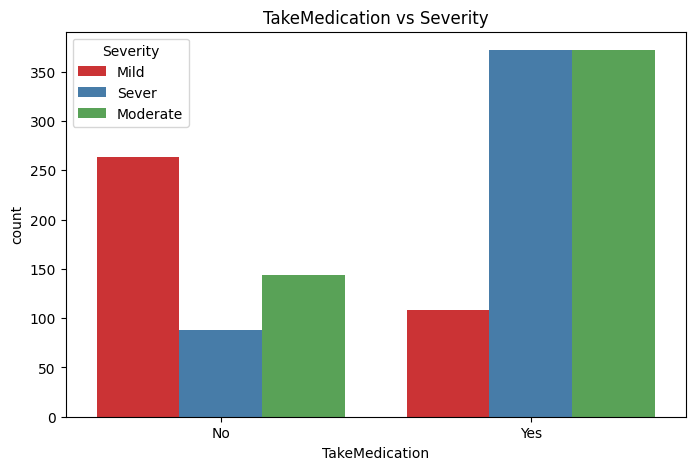

In [134]:
# Relationship: TakeMedication vs Severity
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="TakeMedication", hue="Severity", palette="Set1")

plt.title("TakeMedication vs Severity")
plt.show()

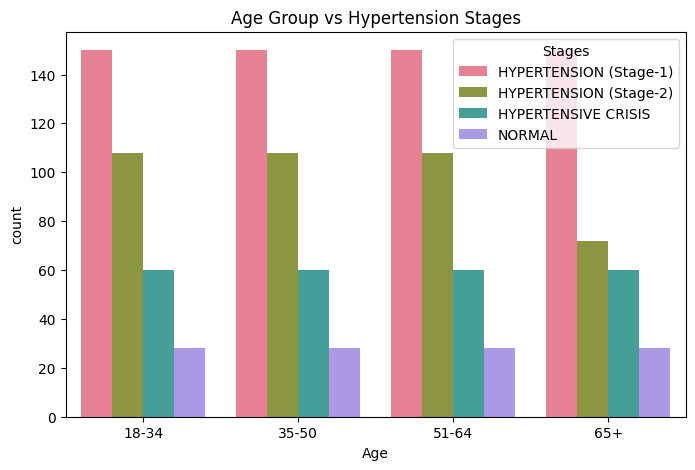

In [135]:
# Age group vs Stages
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Age", hue="Stages", palette="husl")

plt.title("Age Group vs Hypertension Stages")
plt.show()

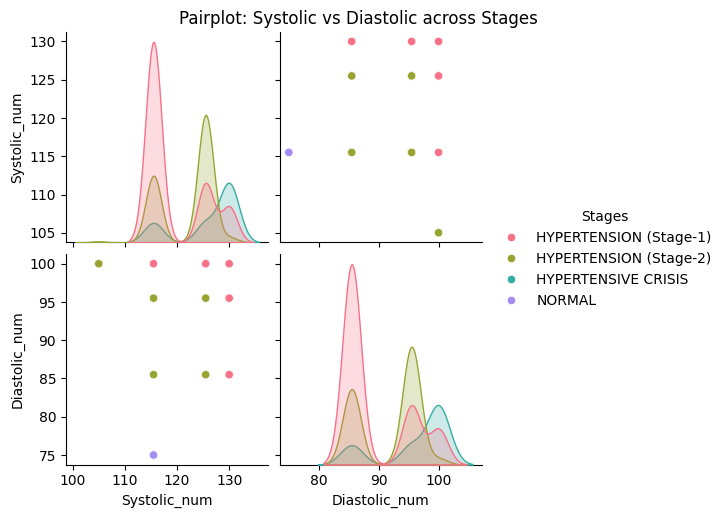

In [137]:
# Pairplot on numeric BP with Stages as hue
sns.pairplot(
    df[['Systolic_num', 'Diastolic_num', 'Stages']],
    hue='Stages',
    diag_kind='kde',
    palette="husl"
)

plt.suptitle("Pairplot: Systolic vs Diastolic across Stages", y=1.02)
plt.show()